## Kap 3 koduppgift 16 

 I denna uppgift ska du göra ett komplett ML-flöde där du modellerar diamantpriser som finns tillgängliga i datasetet “diamonds.csv”. Du kan läsa mer om datasetet här: https://www.kaggle.com/datasets/shivam2503/
diamonds    

In [1]:
import numpy as np
import pandas as pd 


In [2]:
df = pd.read_csv("diamonds.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
# Drop NaNs
df = df.dropna()

# Drop column if it exists
df = df.drop("Unnamed: 0", axis=1, errors="ignore")

# Filter rows where x, y, z are not 0
df = df[(df["x"] != 0) & (df["y"] != 0) & (df["z"] != 0)]

In [7]:
df.drop_duplicates()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [8]:
df["cut"] = df["cut"].astype("category")
df["color"] = df["color"].astype("category")
df["clarity"] = df["clarity"].astype("category")   

In [9]:
df = df[df["price"] < 10000]

In [10]:
df["cut"] = df["cut"].str.lower()

In [11]:
df["price_per_carat"] = df["price"] / df["carat"]

In [12]:
df.describe()

,carat,depth,table,price,x,y,z,price_per_carat
count,48705.000000,48705.000000,48705.000000,48705.000000,48705.000000,48705.000000,48705.000000,48705.000000
mean,0.696741,61.760384,57.410050,2891.848763,5.523528,5.526942,3.412650,3575.674037
std,0.357454,1.430850,2.231265,2399.539987,0.951830,0.951868,0.604457,1505.443863
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,1051.162791
25%,0.380000,61.100000,56.000000,892.000000,4.640000,4.660000,2.860000,2367.647059
50%,0.600000,61.800000,57.000000,2025.000000,5.430000,5.440000,3.350000,3294.827586
75%,1.010000,62.500000,59.000000,4405.000000,6.380000,6.370000,3.950000,4458.928571
max,3.110000,79.000000,79.000000,9999.000000,9.240000,31.800000,31.800000,10589.010989


In [15]:
x = df.drop("price", axis=1)
y = df["price"]

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ["carat", "depth", "table"]
cat_cols = ["cut", "color", "clarity"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [19]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
ypred = model.predict(x_test)   

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, ypred)
print("Mean Squared Error:", mse)
print("r2_score:", model.score(x_test, y_test))



Mean Squared Error: 459211.7819698867
r2_score: 0.9192278613923184


In [22]:
from sklearn.ensemble import RandomForestRegressor
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10]}

grid_search = GridSearchCV(model_rf, param_grid, cv=5)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
ypred_rf = best_rf.predict(x_test)
mse_rf = mean_squared_error(y_test, ypred_rf)
print("Random Forest Mean Squared Error:", mse_rf)
print("Random Forest r2_score:", best_rf.score(x_test, y_test))


Best Parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Random Forest Mean Squared Error: 128837.78583926949
Random Forest r2_score: 0.9773383351553495


I denna uppgift byggdes ett komplett maskininlärningsflöde för att predicera diamantpriser. Efter datastädning och feature engineering tränades både en linjär regressionsmodell och en Random Forest-modell med hjälp av scikit-learn.

Resultaten visar att Random Forest-modellen presterade bäst, med ett R²-värde på cirka 0.98 och ett MSE på cirka 130 330. Detta innebär att modellen kan förklara nästan all variation i diamantpriserna, vilket tyder på mycket god prediktionsförmåga.

De bästa hyperparametrarna var max_depth = None och n_estimators = 200, vilket innebär att modellen gynnas av djupa träd och ett större antal estimators. Detta tyder på att relationerna i datan är komplexa och icke-linjära, vilket Random Forest kan hantera bättre än en linjär modell.

Sammanfattningsvis visar resultaten att maskininlärningsmodeller, särskilt Random Forest, är effektiva för att modellera diamantpriser. Modellen skulle kunna förbättras ytterligare genom att testa fler hyperparametrar eller inkludera fler relevanta variabler.


## Visualiseringar

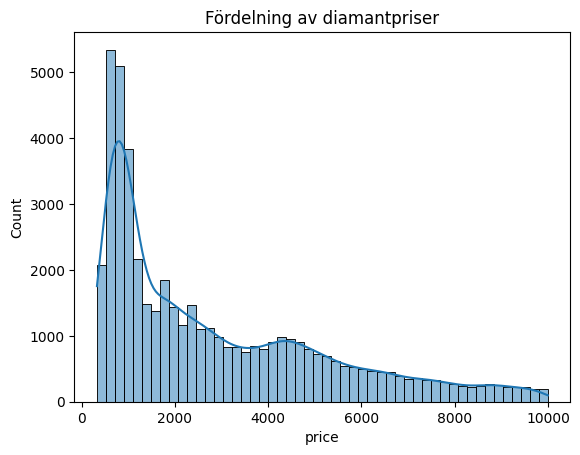

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins=50, kde=True)
plt.title("Fördelning av diamantpriser")
plt.show()

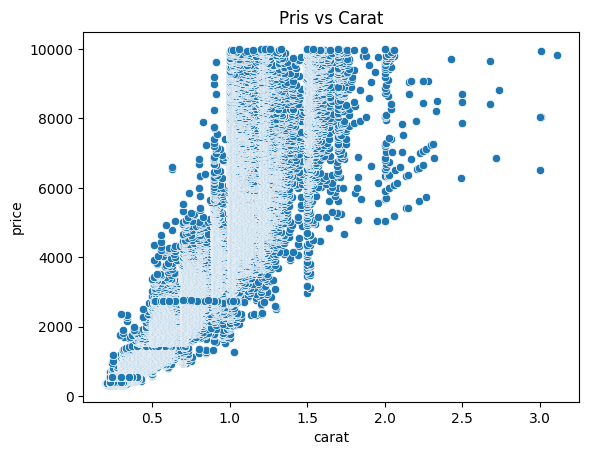

In [25]:
sns.scatterplot(x='carat', y='price', data=df)
plt.title("Pris vs Carat")
plt.show()

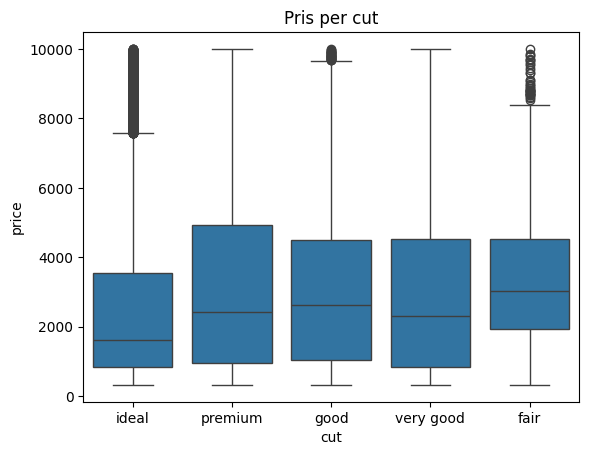

In [26]:
sns.boxplot(x='cut', y='price', data=df)
plt.title("Pris per cut")
plt.show()

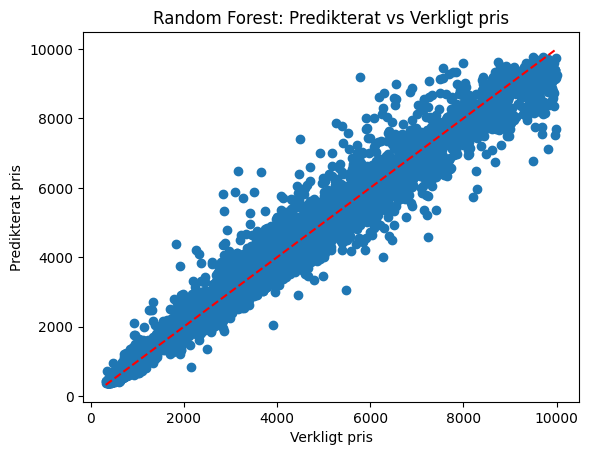

In [27]:
plt.scatter(y_test, ypred_rf)
plt.xlabel("Verkligt pris")
plt.ylabel("Predikterat pris")
plt.title("Random Forest: Predikterat vs Verkligt pris")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

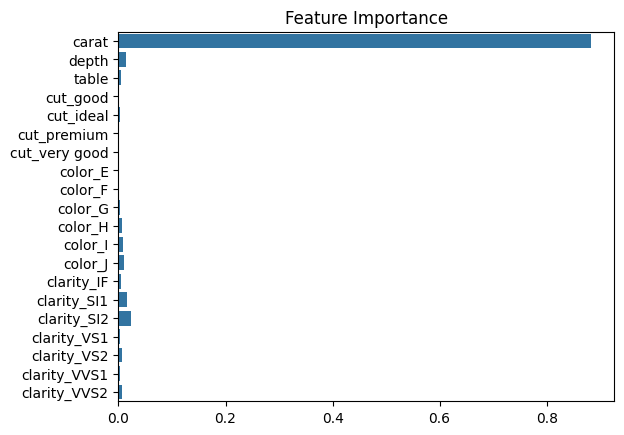

In [28]:
importances = best_rf.named_steps['model'].feature_importances_
features = num_cols + list(best_rf.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()